In [6]:
#!pip install openpyxl

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [36]:
fresh_train_path = "/content/Strawberry fresh.csv.xlsx"
rotten_train_path = "/content/Strawberry rotten.csv.xlsx"

fresh_test_path = "/content/strawberry_fresh_test.xlsx"
rotten_test_path = "/content/strawberry_rotten_test.xlsx"
print(fresh_train.columns)
print(rotten_train.columns)
print(fresh_test.columns)
print(rotten_test.columns)
fresh_train = pd.read_excel(fresh_train_path)
rotten_train = pd.read_excel(rotten_train_path)

fresh_test = pd.read_excel(fresh_test_path)
rotten_test = pd.read_excel(rotten_test_path)

print("Fresh train shape:", fresh_train.shape)
print("Rotten train shape:", rotten_train.shape)
print("Fresh test shape:", fresh_test.shape)
print("Rotten test shape:", rotten_test.shape)
# Fresh = 0
fresh_train["label"] = 0
fresh_test["label"] = 0

# Rotten = 1
rotten_train["label"] = 1
rotten_test["label"] = 1
train_df = pd.concat([fresh_train, rotten_train], ignore_index=True)
test_df = pd.concat([fresh_test, rotten_test], ignore_index=True)

print(train_df.head())
print(test_df.head())
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.save")
print("Scaler saved.")

Index(['MQ2', 'MQ3', 'MQ5', 'MQ8', 'MQ135', 'label'], dtype='object')
Index(['MQ2', 'MQ3', 'MQ5', 'MQ8', 'MQ135', 'label'], dtype='object')
Index(['MQ2', 'MQ3', 'MQ5', 'MQ8', 'MQ135', 'label'], dtype='object')
Index(['MQ2', 'MQ3', 'MQ5', 'MQ8', 'MQ135', 'label'], dtype='object')
Fresh train shape: (20556, 5)
Rotten train shape: (37859, 5)
Fresh test shape: (439, 5)
Rotten test shape: (432, 5)
   MQ2  MQ3  MQ5  MQ8  MQ135  label
0   45  103   28   72    551      0
1   54   94   11   77    548      0
2   45   88   16   74    547      0
3   46   90   10   74    550      0
4   50   88   12   73    550      0
   MQ2  MQ3  MQ5  MQ8  MQ135  label
0   45  103   28   72    551      0
1   54   94   11   77    548      0
2   45   88   16   74    547      0
3   46   90   10   74    550      0
4   50   88   12   73    550      0
Training features shape: (58415, 5)
Testing features shape: (871, 5)
Scaler saved.


In [9]:
model = keras.Sequential([
    layers.Input(shape=(5,)),

    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/20
5842/5842 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9999 - loss: 5.2700e-04 - val_accuracy: 1.0000 - val_loss: 2.5178e-04
Epoch 2/20
5842/5842 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 1.0000 - loss: 1.7350e-04 - val_accuracy: 1.0000 - val_loss: 8.8270e-05
Epoch 3/20
5842/5842 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 1.0000 - loss: 1.1164e-04 - val_accuracy: 1.0000 - val_loss: 4.0306e-05
Epoch 4/20
5842/5842 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 1.0000 - loss: 1.2086e-04 - val_accuracy: 1.0000 - val_loss: 1.9556e-05
Epoch 5/20
5842/5842 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 1.0000 - loss: 5.0832e-05 - val_accuracy: 1.0000 - val_loss: 2.9768e-05
Epoch 6/20
5842/5842 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 1.0000 - loss: 4.9456e-05 - val_accuracy: 1.0000 - val_loss: 5.4258e-06
Epoch 7/20
5842/5842 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 1.0000 - loss: 1.3520e-04 - val_accuracy: 1.0000 - val_loss: 5.7705e-06
Epoch 8/20
5842/5842 ━━━━━━

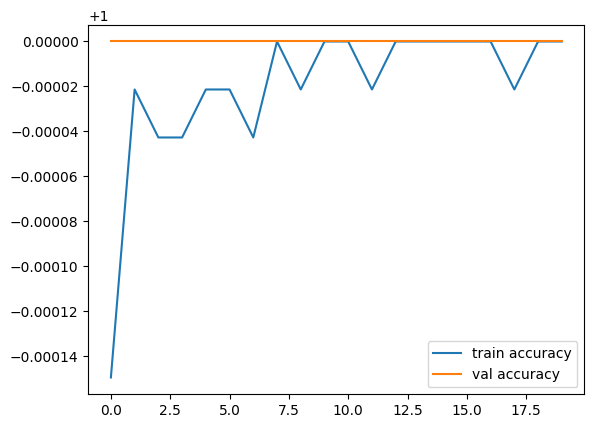

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 3.7807e-05 
Test Accuracy: 100.00%
Test Loss: 0.0000


In [12]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       439
           1       1.00      1.00      1.00       432

    accuracy                           1.00       871
   macro avg       1.00      1.00      1.00       871
weighted avg       1.00      1.00      1.00       871



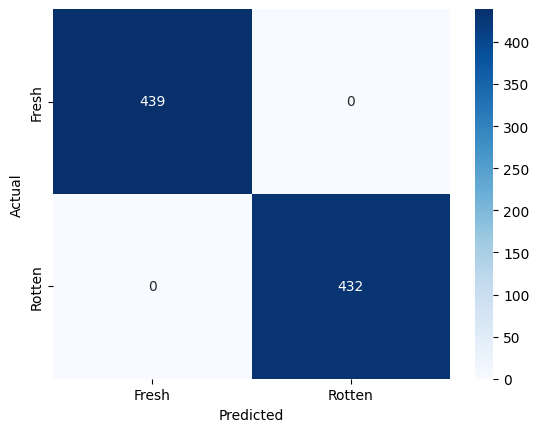

In [13]:
predictions = model.predict(X_test)
pred_classes = (predictions > 0.5).astype(int)

print(classification_report(y_test, pred_classes))
cm = confusion_matrix(y_test, pred_classes)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fresh','Rotten'],
    yticklabels=['Fresh','Rotten']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
model.save("fruit_freshness_model.h5")
print("Model saved.")
model.save("fruit_freshness_model.h5")
print("Model saved.")

Model saved.
Model saved.


In [15]:
def representative_data_gen():
    for i in range(len(X_train)):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quant_model = converter.convert()

with open("fruit_model_int8.tflite", "wb") as f:
    f.write(quant_model)

print("INT8 TFLite model saved for STM32.")

Saved artifact at '/tmp/tmpvyzdd94d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137870157381264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137870157380304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137870157366288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137870157378384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137870157379920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137870157379536: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TFLite model saved for STM32.


In [18]:
import os

print("Float model size:",
      os.path.getsize("fruit_model_int8.tflite")/1024,
      "KB")

print("INT8 model size:",
      os.path.getsize("fruit_model_int8.tflite")/1024,
      "KB")

Float model size: 3.1875 KB
INT8 model size: 3.1875 KB


In [33]:
manual_input = np.array([[45,120,25,105,794]])

manual_scaled = scaler.transform(manual_input)

prediction = model.predict(manual_scaled)[0][0]

if prediction > 0.5:
    print("Prediction: ROTTEN")
    print("Confidence:", prediction*100, "%")
else:
    print("Prediction: FRESH")
    print("Confidence:", (1-prediction)*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediction: FRESH
Confidence: 100.0 %


In [20]:
manual_input = np.array([[120,300,90,210,1400]])

manual_scaled = scaler.transform(manual_input)

prediction = model.predict(manual_scaled)[0][0]

if prediction > 0.5:
    print("Prediction: ROTTEN")
    print("Confidence:", prediction*100, "%")
else:
    print("Prediction: FRESH")
    print("Confidence:", (1-prediction)*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Prediction: ROTTEN
Confidence: 99.9999 %


In [34]:
print(model.input_shape)

(None, 5)


In [35]:
print(scaler.n_features_in_)

5


In [37]:
print("Mean:", scaler.mean_)
print("Std:", scaler.scale_)

Mean: [ 134.63149876  529.60772062  327.79090987  585.58406231 1813.49026791]
Std: [ 72.74553803 278.31779565 256.96472218 350.74140164 847.7146359 ]


In [2]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="fruit_model_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT DETAILS:")
print(input_details)

print("\nOUTPUT DETAILS:")
print(output_details)

INPUT DETAILS:
[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([1, 5], dtype=int32), 'shape_signature': array([-1,  5], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.015845218673348427, -25), 'quantization_parameters': {'scales': array([0.01584522], dtype=float32), 'zero_points': array([-25], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

OUTPUT DETAILS:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
